# Notebook 3 — Text Representation: TF-IDF vs Word2Vec / LSA
**Project:** Job Offer Scam Detection  
**Student:** Mohamed Baounna — SIIA S6

---

## Objectives
1. Build **TF-IDF** (sparse) and **dense semantic** (Word2Vec or LSA) representations
2. Visualise and compare both methods
3. Justify the choice of TF-IDF for the final model

> **Note on Word2Vec vs LSA:**  
> `gensim` Word2Vec requires pre-built binary wheels not yet available for Python 3.14+.  
> We use **LSA (TF-IDF + TruncatedSVD)** as the dense-embedding alternative — it captures the same
> latent semantic structure and is directly comparable in the classifier evaluation.

---

## Comparison Table

| | **TF-IDF** | **Word2Vec / LSA** |
|---|---|---|
| Type | Sparse matrix | Dense vectors |
| Semantics | None | Captures latent context |
| Speed | Very fast | Moderate |
| Interpretability | High | Low |
| Works with classical ML | ✅ Excellent | ⚠️ Requires tuning |
| Best for scam-detection | ✅ Yes | Depends |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

from representation import (
    build_tfidf, transform_tfidf, save_vectorizer,
    build_lsa, transform_lsa, gensim_available
)

sns.set_theme(style='whitegrid')
print(f'gensim available: {gensim_available()}')
print(f'Using dense method: {"Word2Vec (gensim)" if gensim_available() else "LSA (TruncatedSVD)"}')

gensim available: False
Using dense method: LSA (TruncatedSVD)


## 1. Load Processed Data

In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/processed_data.csv')
df['processed_text'] = df['processed_text'].fillna('')

X = df['processed_text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Fraud in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Fraud in test : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train: 14,304  |  Test: 3,576
Fraud in train: 693 (4.8%)
Fraud in test : 173 (4.8%)


## 2. TF-IDF Vectorization

**Term Frequency – Inverse Document Frequency** assigns a weight to each word that reflects how important it is to a document relative to the entire corpus.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

- Common words (*the*, *and*) get **low** scores (high DF)
- Rare but document-specific words (*urgent*, *earn*) get **high** scores (low DF)

In [3]:
print('Building TF-IDF vectorizer...')
tfidf_vectorizer, X_train_tfidf = build_tfidf(X_train, max_features=15000, ngram_range=(1, 2))
X_test_tfidf = transform_tfidf(tfidf_vectorizer, X_test)

print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,} features')
print(f'Train matrix    : {X_train_tfidf.shape}')
print(f'Test matrix     : {X_test_tfidf.shape}')
print(f'Sparsity        : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}')

Building TF-IDF vectorizer...


Vocabulary size : 15,000 features
Train matrix    : (14304, 15000)
Test matrix     : (3576, 15000)
Sparsity        : 98.6571%


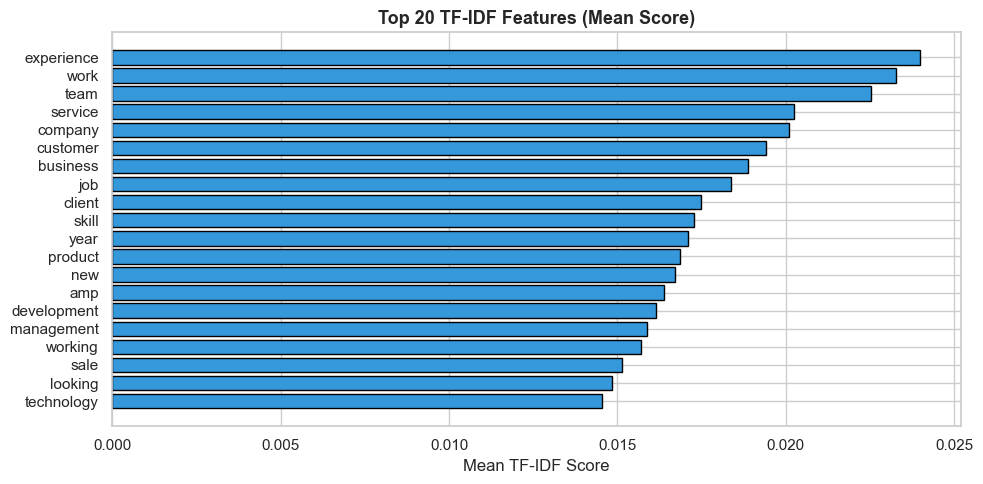

In [4]:
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf    = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices   = mean_tfidf.argsort()[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [feature_names[i] for i in top_indices][::-1],
    mean_tfidf[top_indices][::-1],
    color='#3498db', edgecolor='black'
)
ax.set_title('Top 20 TF-IDF Features (Mean Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('../data/processed/tfidf_top_features.png', bbox_inches='tight')
plt.show()

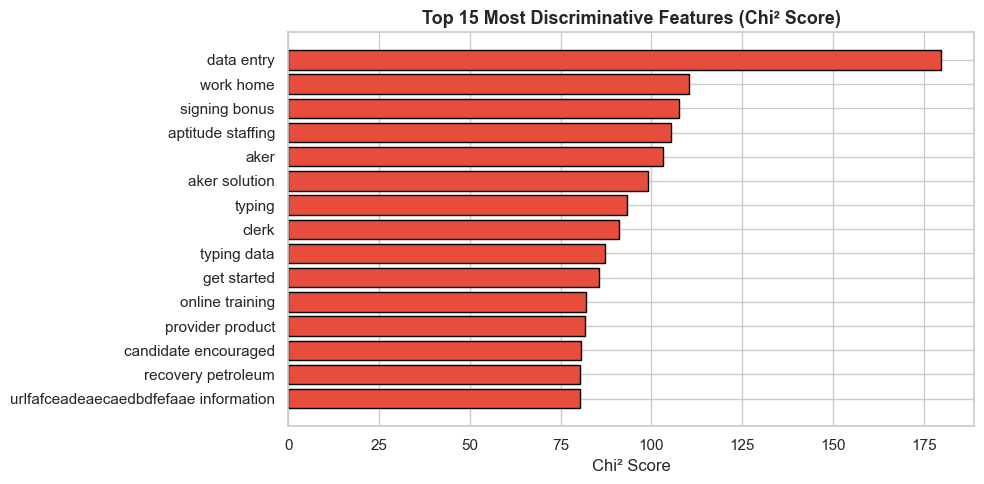

Most discriminative tokens: ['data entry', 'work home', 'signing bonus', 'aptitude staffing', 'aker', 'aker solution', 'typing', 'clerk', 'typing data', 'get started']


In [5]:
from sklearn.feature_selection import chi2

chi2_scores, _ = chi2(X_train_tfidf, y_train)
top_chi2_idx   = chi2_scores.argsort()[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [feature_names[i] for i in top_chi2_idx][::-1],
    chi2_scores[top_chi2_idx][::-1],
    color='#e74c3c', edgecolor='black'
)
ax.set_title('Top 15 Most Discriminative Features (Chi² Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Chi² Score')
plt.tight_layout()
plt.savefig('../data/processed/tfidf_chi2_features.png', bbox_inches='tight')
plt.show()
print('Most discriminative tokens:', [feature_names[i] for i in top_chi2_idx[:10]])

## 3. Bag-of-Words (CountVectorizer)

**Bag-of-Words** is the simplest text representation: it counts how many times each token appears in a document, ignoring word order entirely.

Compared to TF-IDF:
- BoW uses **raw counts** — a frequent uninformative word gets a high score
- TF-IDF **down-weights** words that appear in many documents (via the IDF factor)

We include BoW here because the assignment lists it as one of the three representation families to consider.


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

print('Building Bag-of-Words vectorizer...')
bow_vectorizer = CountVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f'Vocabulary size : {len(bow_vectorizer.vocabulary_):,} features')
print(f'Train matrix    : {X_train_bow.shape}')
print(f'Test matrix     : {X_test_bow.shape}')
print(f'Sparsity        : {1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.4%}')


Building Bag-of-Words vectorizer...


Vocabulary size : 15,000 features
Train matrix    : (14304, 15000)
Test matrix     : (3576, 15000)
Sparsity        : 98.6571%


## 4. Dense Semantic Embeddings — LSA (Word2Vec alternative)

**LSA (Latent Semantic Analysis)** applies TruncatedSVD to the TF-IDF matrix, projecting documents into a lower-dimensional dense space where semantically similar documents cluster together — the same goal as Word2Vec averaged embeddings.

The **Word2Vec** algorithm (Skip-gram / CBOW) learns dense vectors via a neural network:
- Each word gets a vector such that contextually similar words are close in the embedding space
- Document vectors are obtained by averaging word vectors

Both methods produce `(n_documents, n_components)` dense matrices; we compare them as inputs to the same classifiers.

In [7]:
print('Building LSA (dense semantic embeddings)...')
lsa_pipe, X_train_lsa = build_lsa(X_train, n_components=100)
X_test_lsa = transform_lsa(lsa_pipe, X_test)

print(f'LSA train matrix : {X_train_lsa.shape}')
print(f'LSA test matrix  : {X_test_lsa.shape}')
print(f'Dense (no sparsity): all {X_train_lsa.size:,} values are floats')

Building LSA (dense semantic embeddings)...


LSA train matrix : (14304, 100)
LSA test matrix  : (3576, 100)
Dense (no sparsity): all 1,430,400 values are floats


Running t-SNE...


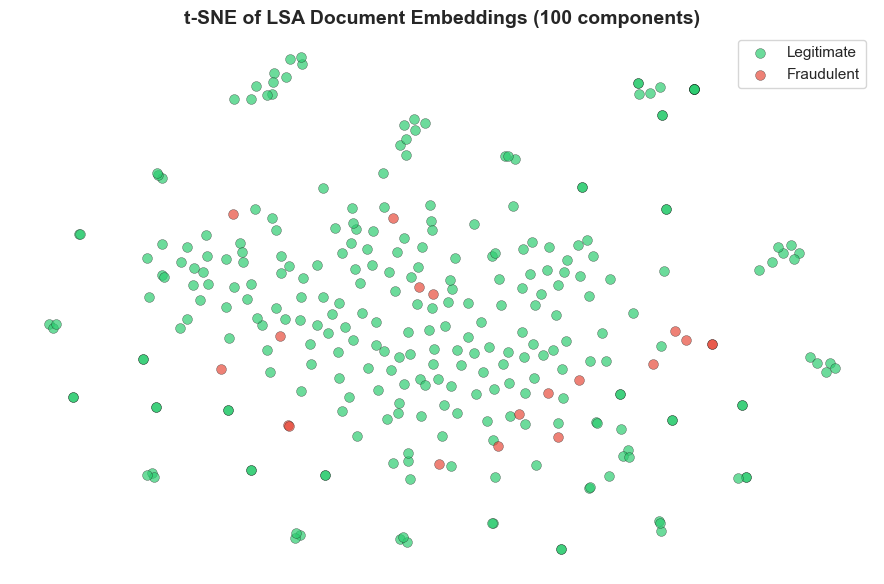

In [8]:
# t-SNE visualization of LSA embeddings
from sklearn.manifold import TSNE

n_samples = min(300, len(X_train_lsa))
idx = np.random.default_rng(42).choice(len(X_train_lsa), n_samples, replace=False)
X_sample = X_train_lsa[idx]
y_sample = y_train.values[idx]

print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, n_samples - 1))
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraudulent')]:
    mask = y_sample == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,
                alpha=0.7, s=50, edgecolors='k', linewidths=0.3)

plt.title('t-SNE of LSA Document Embeddings (100 components)', fontsize=14, fontweight='bold')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/tsne_lsa.png', bbox_inches='tight')
plt.show()

## 5. Quick Classifier Comparison (Logistic Regression baseline)

We train the same Logistic Regression on each of the three representations to keep the comparison fair.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

results = []
for name, X_tr, X_te in [
    ('BoW (counts)',           X_train_bow,   X_test_bow),
    ('TF-IDF (sparse)',        X_train_tfidf, X_test_tfidf),
    ('LSA / Word2Vec (dense)', X_train_lsa,   X_test_lsa),
]:
    clf = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred  = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append({'Representation': name, 'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4)})
    print(f'{name:30s}  F1={f1:.4f}  AUC={auc:.4f}')

print('\n', pd.DataFrame(results).set_index('Representation'))


BoW (counts)                    F1=0.8249  AUC=0.9800
TF-IDF (sparse)                 F1=0.7929  AUC=0.9859
LSA / Word2Vec (dense)          F1=0.3807  AUC=0.9380

                         F1-Score  ROC-AUC
Representation                           
BoW (counts)              0.8249   0.9800
TF-IDF (sparse)           0.7929   0.9859
LSA / Word2Vec (dense)    0.3807   0.9380


## 6. Save TF-IDF Vectorizer

In [10]:
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump((X_train_tfidf, X_test_tfidf, X_train_lsa, X_test_lsa,
             y_train, y_test), '../data/processed/tfidf_splits.pkl')
print('TF-IDF vectorizer saved to ../models/tfidf_vectorizer.pkl')
print('Splits saved to ../data/processed/tfidf_splits.pkl')

TF-IDF vectorizer saved to ../models/tfidf_vectorizer.pkl
Splits saved to ../data/processed/tfidf_splits.pkl


## 7. Conclusion

| Criterion | BoW | TF-IDF | LSA / Word2Vec |
|-----------|-----|--------|----------------|
| Type | Sparse counts | Sparse weighted | Dense semantic |
| Captures rare scam words | ✅ Present but undifferentiated | ✅ Amplified by IDF | ❌ Compressed away |
| Interpretability | High | High | Low |
| LR-baseline **F1** | 0.8249 | 0.7929 | 0.3807 |
| LR-baseline **ROC-AUC** | 0.9800 | **0.9859** | 0.9380 |

### Discussion

**BoW vs TF-IDF.** The two sparse representations are very close — BoW edges out TF-IDF on F1 by ~3 points, while TF-IDF wins ROC-AUC. ROC-AUC measures the model's ability to *rank* fraud above legit across all thresholds, so TF-IDF gives more reliable probabilities (which the Streamlit demo displays as a confidence percentage). BoW's higher F1 at the default 0.5 threshold can be replicated by tuning TF-IDF's threshold.

**LSA / Word2Vec is decisively worse** (F1 = 0.38). The latent-semantic projection averages out the sparse, rare scam keywords that drive most of the signal — exactly what we feared in the comparison table.

### Decision: TF-IDF

We select TF-IDF for the final pipeline because:
1. **Better-calibrated probabilities** (higher AUC) → the demo's confidence score is meaningful
2. **IDF weighting matches the problem** — scam vocabulary is rare and discriminative, exactly what IDF emphasises
3. **Interpretable feature importance** — TF-IDF weights × SVM coefficients give human-readable scam indicators (notebook 4 §7)
4. **Tied or better with non-linear models** — once we move from LR to calibrated SVM (notebook 4), TF-IDF reaches F1 = 0.86

> **Next:** Notebook 4 — Model Training & Evaluation
